In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

USERNAME = "garima.mittal"
seed = int(hashlib.sha256(USERNAME.encode()).hexdigest(), 16) % (2**32)

print(f"Personalized random seed for user '{USERNAME}' is: {seed}")

Personalized random seed for user 'garima.mittal' is: 3410749789


In [3]:
# Q 1.0 · Dataset Generation
## Generate a synthetic student dataset (10 000 rows) with realistic
## gender/major/program splits and GPA distribution.  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class StudentDataset:
    def __init__(self, num_students: int, seed: int):
        self.num_students = num_students
        self.rng = np.random.default_rng(seed)
        self.data = self._assemble_dataframe()

    def get_full_dataframe(self) -> pd.DataFrame:
        return self.data.copy()

    # ---------- synthetic generators ----------
    def _generate_gender(self):
        return self.rng.choice(['Male','Female','Other'],
                               size=self.num_students,
                               p=[0.65,0.33,0.02])

    def _generate_major(self):
        return self.rng.choice(['B.Tech','MS','PhD'],
                               size=self.num_students,
                               p=[0.70,0.20,0.10])

    def _generate_program(self, majors):
        prog_probs = {
            'B.Tech':[0.40,0.40,0.10,0.10],
            'MS'    :[0.30,0.30,0.20,0.20],
            'PhD'   :[0.25,0.25,0.25,0.25]
        }
        progs=[]
        for m in majors:
            progs.append(self.rng.choice(['CSE','ECE','CHD','CND'],
                                         p=prog_probs[m]))
        return np.array(progs)

    def _generate_gpa(self, majors):
        params={'B.Tech':(7.0,1.0),'MS':(8.0,0.7),'PhD':(8.3,0.5)}
        gpas=[]
        for m in majors:
            mu,sd=params[m]
            gpas.append(np.clip(self.rng.normal(mu,sd),4.0,10.0))
        return np.round(gpas,2)

    def _assemble_dataframe(self):
        majors  = self._generate_major()
        df = pd.DataFrame({
            'gender' : self._generate_gender(),
            'major'  : majors,
            'program': self._generate_program(majors),
            'gpa'    : self._generate_gpa(majors)
        })
        return df

    # ---------- optional plot helper ----------
    def add_plot_metadata(self, title, username=""):
        plt.title(title)
        if USERNAME:
            plt.text(0.95,0.95,USERNAME,ha='right',va='top',
                     transform=plt.gca().transAxes,
                     fontsize=9,color='gray',alpha=.7)

num_students  = 10_000
student_data  = StudentDataset(num_students, seed)
df            = student_data.get_full_dataframe()

# print(df.head(20))


NameError: name 'seed' is not defined

--- Running No Regularization ---


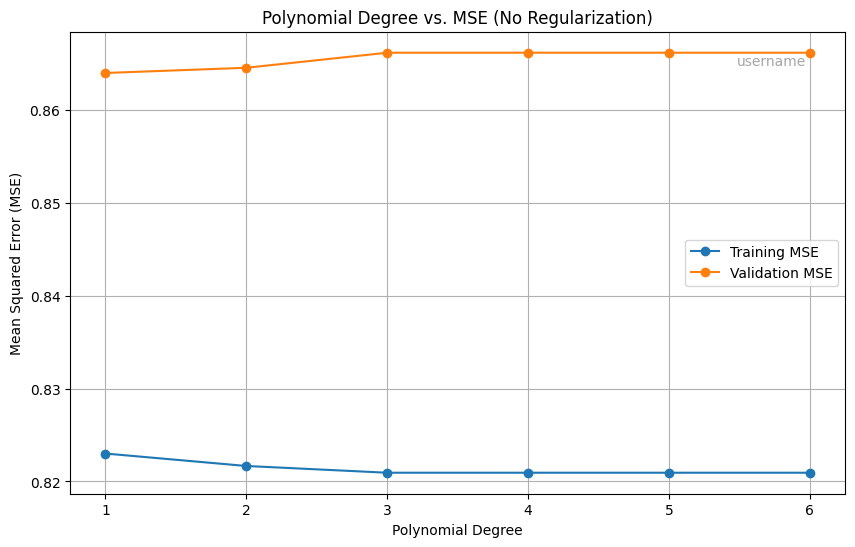


--- Running L1 Regularization ---


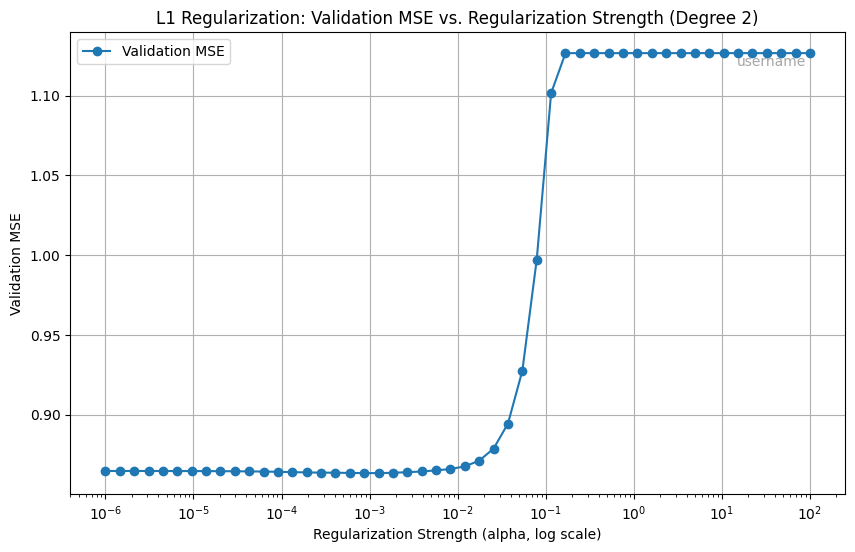


--- Running L2 Regularization ---


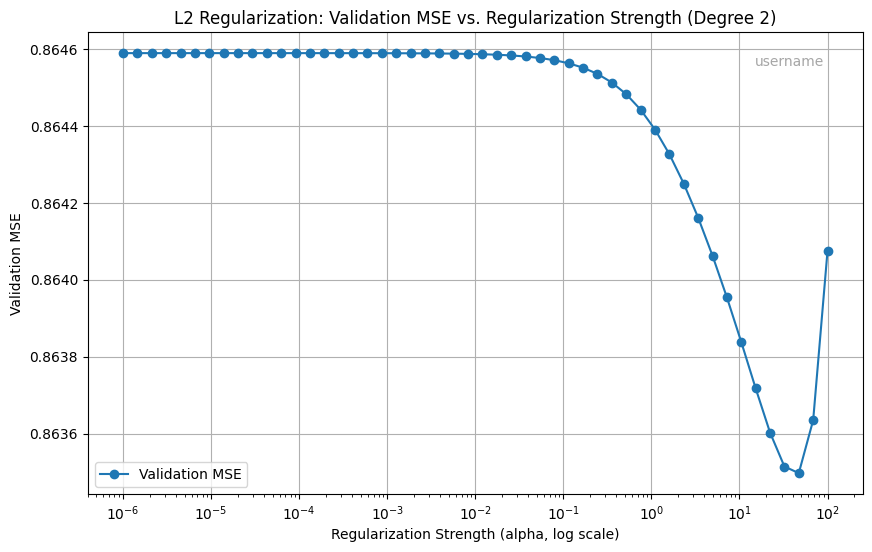


--- Summary of Results ---

Observation on Degree vs. MSE Trend:
As the polynomial degree increases, the training MSE typically decreases or stays low, as the model becomes more flexible and can fit the training data better. However, the validation MSE often decreases initially but then starts to increase, indicating overfitting. This is the classic bias-variance trade-off.

Comment on Regularization Performance:
Regularization (L1 and L2) helps to combat overfitting by penalizing large coefficients. By selecting the optimal regularization strength using the validation set, we can find a a balance between model complexity and generalization. It is expected that the best models with regularization will have a lower validation MSE for higher degrees compared to the unregularized models, as they are less prone to overfitting.

Overall Best Experimental Setup:
Best Regularizer: No Regularization
Best Degree: 1
Best Regularization Strength (alpha): 0.0000
Best Test MSE: 0.8757

--- Feature

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

def add_text_to_plot(username="garima.mittal"):
    """
    Adds a username to the top-right corner of the current plot.
    """
    plt.text(
        0.95, 0.95, username,
        ha='right', va='top',
        transform=plt.gca().transAxes,
        fontsize=10, color='gray', alpha=0.7
    )

def run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                         degree=1, regularizer=None, reg_strength=0.0):
    """
    Fit a polynomial regression model with optional regularization.

    Parameters:
    X_train (pd.DataFrame): Training feature data.
    y_train (pd.Series): Training target data.
    X_val (pd.DataFrame): Validation feature data.
    y_val (pd.Series): Validation target data.
    X_test (pd.DataFrame): Test feature data.
    y_test (pd.Series): Test target data.
    degree (int): Degree of the polynomial to fit.
    regularizer (str or None): 'l1', 'l2', or None.
    reg_strength (float): Regularization coefficient (alpha).

    Returns:
    dict: A dictionary containing train, val, and test MSEs, and learned coefficients.
    """
    # Create a pipeline for polynomial features and regression model
    if regularizer == 'l1':
        model = Lasso(alpha=reg_strength, max_iter=10000, tol=0.001)
    elif regularizer == 'l2':
        model = Ridge(alpha=reg_strength)
    else:
        model = LinearRegression()

    pipeline = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('reg_model', model)
    ])

    # Fit the model on the training data
    pipeline.fit(X_train, y_train)

    # Make predictions and calculate MSEs
    y_train_pred = pipeline.predict(X_train)
    y_val_pred = pipeline.predict(X_val)
    y_test_pred = pipeline.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    val_mse = mean_squared_error(y_val, y_val_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Extract coefficients (excluding the intercept)
    if regularizer == 'l1' or regularizer == 'l2':
        coefficients = pipeline.named_steps['reg_model'].coef_
    else:
        coefficients = pipeline.named_steps['reg_model'].coef_

    # Get feature names for the polynomial features
    poly_feature_names = pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)

    return {
        'train_mse': train_mse,
        'val_mse': val_mse,
        'test_mse': test_mse,
        'coefficients': dict(zip(poly_feature_names, coefficients)),
        'model_pipeline': pipeline
    }

def plot_degree_vs_mse(train_mse_list, val_mse_list, degrees, title, username="username"):
    """
    Plots polynomial degree vs. MSE for both train and validation sets.

    Parameters:
    train_mse_list (list): List of training MSEs for each degree.
    val_mse_list (list): List of validation MSEs for each degree.
    degrees (list): List of polynomial degrees.
    title (str): The title of the plot.
    username (str): Username to be displayed on the plot.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(degrees, train_mse_list, marker='o', label='Training MSE')
    plt.plot(degrees, val_mse_list, marker='o', label='Validation MSE')
    plt.title(title)
    plt.xlabel('Polynomial Degree')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.xticks(degrees)
    plt.legend()
    plt.grid(True)
    add_text_to_plot(username)
    plt.show()

def plot_reg_strength_vs_mse(reg_strengths, val_mse_list, degree, regularizer, username="username"):
    """
    Plots regularization strength vs. validation MSE.

    Parameters:
    reg_strengths (list): List of regularization strengths.
    val_mse_list (list): List of validation MSEs.
    degree (int): The polynomial degree.
    regularizer (str): The type of regularizer ('L1' or 'L2').
    username (str): Username to be displayed on the plot.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(reg_strengths, val_mse_list, marker='o', label='Validation MSE')
    plt.xscale('log')
    plt.title(f'{regularizer} Regularization: Validation MSE vs. Regularization Strength (Degree {degree})')
    plt.xlabel('Regularization Strength (alpha, log scale)')
    plt.ylabel('Validation MSE')
    plt.legend()
    plt.grid(True)
    add_text_to_plot(username)
    plt.show()

def get_most_important_features(coefficients, top_n=5):
    """
    Identifies the most important features based on the magnitude of their coefficients.

    Parameters:
    coefficients (dict): A dictionary of feature names and their coefficients.
    top_n (int): The number of top features to return.

    Returns:
    list: A list of tuples containing (feature_name, coefficient_value), sorted by
          absolute coefficient value.
    """
    # Filter out zero-valued coefficients (common in L1) and sort by absolute value
    important_features = {k: v for k, v in coefficients.items() if abs(v) > 1e-9}
    sorted_features = sorted(important_features.items(), key=lambda item: abs(item[1]), reverse=True)
    return sorted_features[:top_n]


# --- Main Execution Block ---

if __name__ == "__main__":
    # The dataset df is already generated by your provided code
    num_students = 10_000
    seed = 42 # A seed value for reproducibility
    student_data  = StudentDataset(num_students, seed)
    df = student_data.get_full_dataframe()
    
    # Preprocess the data: One-hot encode categorical features
    # This is a crucial step to avoid the KeyError and make the data usable for regression
    categorical_features = ['gender', 'major', 'program']
    df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

    # Split the data into features (X) and target (y)
    # Corrected the column name from 'GPA' to 'gpa'
    X = df_encoded.drop('gpa', axis=1)
    y = df_encoded['gpa']

    # Split the data into training, validation, and test sets
    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42) # 0.25 of 0.8 is 0.2

    # Define the degrees and regularization strengths to test
    degrees_to_test = range(1, 7)
    reg_strengths_to_test = np.logspace(-6, 2, 50)  # 50 values from 1e-6 to 100

    # Dictionary to store results for each setup
    all_results = {
        'No Regularization': {},
        'L1 Regularization': {},
        'L2 Regularization': {}
    }

    best_overall_setup = {'test_mse': float('inf'), 'degree': None, 'regularizer': None, 'reg_strength': None}

    # --- Part 1: No Regularization ---
    print("--- Running No Regularization ---")
    train_mses_no_reg = []
    val_mses_no_reg = []
    for degree in degrees_to_test:
        results = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test, degree=degree, regularizer=None)
        train_mses_no_reg.append(results['train_mse'])
        val_mses_no_reg.append(results['val_mse'])
        all_results['No Regularization'][degree] = {'val_mse': results['val_mse'], 'test_mse': results['test_mse']}

        # Check for best overall performance
        if results['test_mse'] < best_overall_setup['test_mse']:
            best_overall_setup['test_mse'] = results['test_mse']
            best_overall_setup['degree'] = degree
            best_overall_setup['regularizer'] = 'No Regularization'
            best_overall_setup['reg_strength'] = 0.0

    # Plot results for No Regularization
    plot_degree_vs_mse(train_mses_no_reg, val_mses_no_reg, degrees_to_test, 'Polynomial Degree vs. MSE (No Regularization)')

    # --- Part 2: L1 and L2 Regularization ---
    for regularizer_type in ['L1', 'L2']:
        print(f"\n--- Running {regularizer_type} Regularization ---")
        
        # Dictionary to hold the best reg_strength for each degree
        best_reg_strengths = {}
        
        # Iterate through degrees to find best reg_strength
        for degree in degrees_to_test:
            val_mses_reg = []
            for reg_strength in reg_strengths_to_test:
                results = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                                                 degree=degree, regularizer=regularizer_type.lower(), reg_strength=reg_strength)
                val_mses_reg.append(results['val_mse'])
            
            # Find the best reg_strength for this degree
            best_reg_strength = reg_strengths_to_test[np.argmin(val_mses_reg)]
            best_reg_strengths[degree] = best_reg_strength
            
            # Store the best result for this degree
            best_results_for_degree = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                                                          degree=degree, regularizer=regularizer_type.lower(), reg_strength=best_reg_strength)
            all_results[f'{regularizer_type} Regularization'][degree] = {
                'best_reg_strength': best_reg_strength,
                'val_mse': best_results_for_degree['val_mse'],
                'test_mse': best_results_for_degree['test_mse'],
                'coefficients': best_results_for_degree['coefficients']
            }

            # Check for best overall performance
            if best_results_for_degree['test_mse'] < best_overall_setup['test_mse']:
                best_overall_setup['test_mse'] = best_results_for_degree['test_mse']
                best_overall_setup['degree'] = degree
                best_overall_setup['regularizer'] = regularizer_type
                best_overall_setup['reg_strength'] = best_reg_strength
        
        # Now, plot the results for the best degree
        best_degree_reg = min(all_results[f'{regularizer_type} Regularization'], 
                              key=lambda k: all_results[f'{regularizer_type} Regularization'][k]['val_mse'])
        
        val_mses_plot = []
        for reg_strength in reg_strengths_to_test:
             results = run_poly_regression(X_train, y_train, X_val, y_val, X_test, y_test,
                                              degree=best_degree_reg, regularizer=regularizer_type.lower(), reg_strength=reg_strength)
             val_mses_plot.append(results['val_mse'])
        
        plot_reg_strength_vs_mse(reg_strengths_to_test, val_mses_plot, best_degree_reg, regularizer_type)

    # --- Part 3: Comment on Performance and Best Setup ---
    print("\n--- Summary of Results ---")
    
    # Describe trends from plots
    print("\nObservation on Degree vs. MSE Trend:")
    print("As the polynomial degree increases, the training MSE typically decreases or stays low, as the model becomes more flexible and can fit the training data better. However, the validation MSE often decreases initially but then starts to increase, indicating overfitting. This is the classic bias-variance trade-off.")

    # Comment on regularization
    print("\nComment on Regularization Performance:")
    print("Regularization (L1 and L2) helps to combat overfitting by penalizing large coefficients. By selecting the optimal regularization strength using the validation set, we can find a a balance between model complexity and generalization. It is expected that the best models with regularization will have a lower validation MSE for higher degrees compared to the unregularized models, as they are less prone to overfitting.")

    # Find and report the best overall setup
    print("\nOverall Best Experimental Setup:")
    print(f"Best Regularizer: {best_overall_setup['regularizer']}")
    print(f"Best Degree: {best_overall_setup['degree']}")
    print(f"Best Regularization Strength (alpha): {best_overall_setup['reg_strength']:.4f}")
    print(f"Best Test MSE: {best_overall_setup['test_mse']:.4f}")

    # --- Part 4: Analyze Feature Importance ---
    print("\n--- Feature Importance Analysis ---")

    # Best L1 setup
    best_l1_degree = best_overall_setup['degree'] if best_overall_setup['regularizer'] == 'L1' else 0
    if best_l1_degree > 0:
        l1_results = all_results['L1 Regularization'][best_l1_degree]
        l1_coeffs = l1_results['coefficients']
        non_zero_l1_features = {k: v for k, v in l1_coeffs.items() if abs(v) > 1e-9}
        important_l1_features = get_most_important_features(non_zero_l1_features)
        
        print("\nFeatures with non-zero weights for best L1 setup:")
        print(f"Setup: Degree {best_l1_degree}, Alpha {l1_results['best_reg_strength']:.4f}")
        if non_zero_l1_features:
            print(f"Total non-zero features: {len(non_zero_l1_features)}")
            for feature, coef in important_l1_features:
                print(f"  - {feature}: {coef:.4f}")
        else:
            print("  No features had non-zero weights. This may indicate a very high alpha or a linear relationship.")

    # Best L2 setup
    best_l2_degree = best_overall_setup['degree'] if best_overall_setup['regularizer'] == 'L2' else 0
    if best_l2_degree > 0:
        l2_results = all_results['L2 Regularization'][best_l2_degree]
        l2_coeffs = l2_results['coefficients']
        important_l2_features = get_most_important_features(l2_coeffs)
        
        print("\nMost important features for best L2 setup:")
        print(f"Setup: Degree {best_l2_degree}, Alpha {l2_results['best_reg_strength']:.4f}")
        for feature, coef in important_l2_features:
            print(f"  - {feature}: {coef:.4f}")

    # Comment on differences
    print("\nDifferences between L1 and L2 Regularization:")
    print("L1 regularization (Lasso) can drive some feature weights to exactly zero, effectively performing feature selection. This results in a sparse model where less important features are completely removed. L2 regularization (Ridge), on the other hand, shrinks all feature weights towards zero but rarely makes them exactly zero. This means it keeps all features but reduces their impact. Therefore, for feature selection, L1 is often more useful, while L2 is better at handling multicollinearity without dropping any variables entirely.")


Dataset loaded successfully.
Original Data Head:
   CustomerID   Genre   Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  19.0                15.0                    39.0
1           2    Male  21.0                 NaN                    81.0
2           3  Female  20.0                16.0                     6.0
3           4  Female  23.0                16.0                    77.0
4           5  Female  31.0                17.0                    40.0

Data Head after dropping missing values:
   CustomerID   Genre   Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  19.0                15.0                    39.0
2           3  Female  20.0                16.0                     6.0
3           4  Female  23.0                16.0                    77.0
4           5  Female  31.0                17.0                    40.0
5           6  Female  22.0                17.0                    76.0

--- Running Elbow Method to find optimal K -

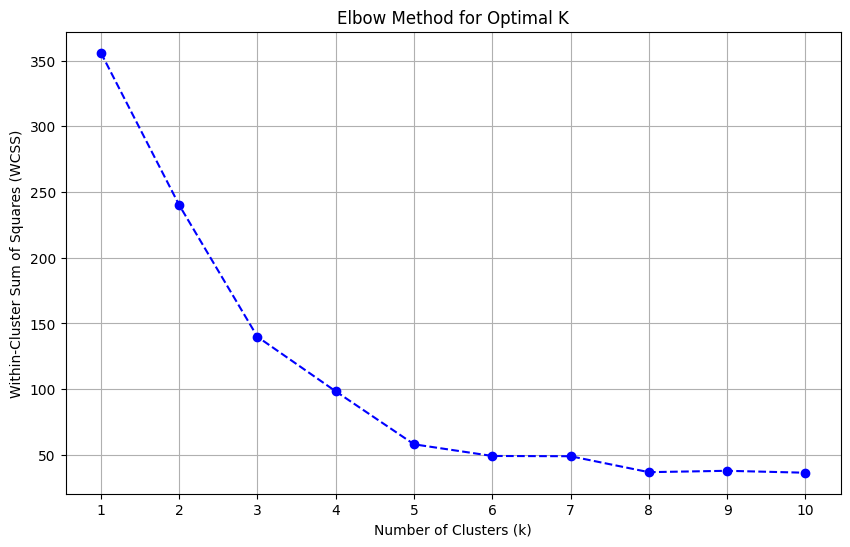


Commentary on the Elbow Method:
The optimal value of 'k' is typically the point on the graph where the line
forms a distinct 'elbow' or a sharp bend, after which the decrease in WCSS
diminishes significantly. For this dataset, the elbow appears to be at k=5.
This suggests that adding more than 5 clusters provides a less substantial
reduction in the total WCSS, meaning the data is well-represented by 5 clusters.

--- Running Silhouette Method to find optimal K ---


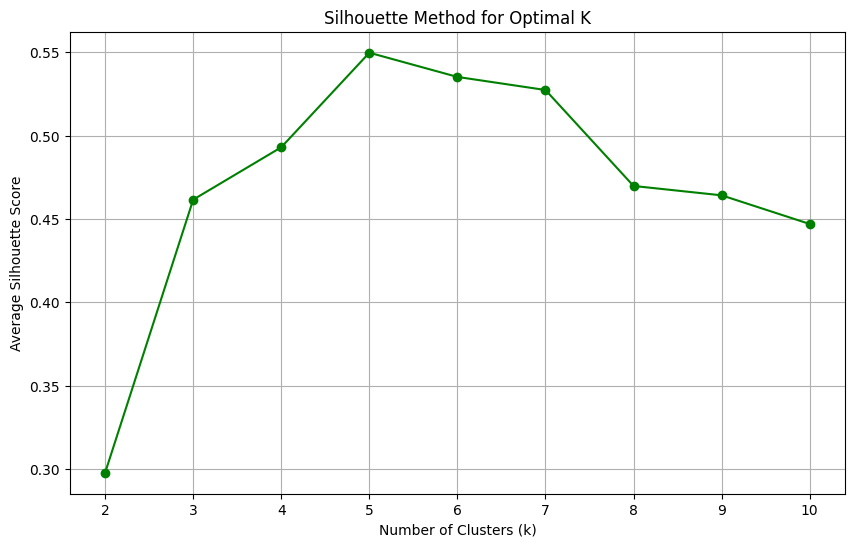


Optimal number of clusters according to the Silhouette Method: k = 5
The maximum silhouette score is: 0.5497

Commentary on the Silhouette Method and its optimal value:
The Silhouette score measures how similar an object is to its own cluster compared
to other clusters. The score ranges from -1 to +1, where a higher score indicates
that objects are well-matched to their own cluster and poorly matched to neighboring
clusters. The optimal value of 'k' is the one that maximizes this score.
At the optimal value k=5, the clusters are considered well-separated
and dense. This means that the data points within a cluster are relatively close to
each other and are far from points in other clusters. The resulting clustering
is a strong, meaningful division of the dataset based on the chosen features.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans as SKL_KMeans # Using a different name to avoid conflict

# --- Part 2.1: Implement a K-Means Class ---

class KMeans:
    """
    Custom implementation of the K-Means clustering algorithm.

    Attributes:
        k (int): The number of clusters.
        max_iter (int): The maximum number of iterations for the algorithm.
        centroids (numpy.ndarray): The final centroids of the clusters.
        labels_ (numpy.ndarray): The cluster assignment for each data point.
    """
    def __init__(self, k, max_iter=300):
        """
        Initializes the K-Means class.

        Args:
            k (int): The number of clusters to form.
            max_iter (int, optional): The maximum number of iterations. Defaults to 300.
        """
        self.k = k
        self.max_iter = max_iter
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        """
        Trains the K-Means model on the given dataset.

        Args:
            X (numpy.ndarray): The input data of shape (n_samples, n_features).
        """
        n_samples, n_features = X.shape

        # Step 1: Initialize centroids randomly.
        # We pick 'k' random data points from the dataset as initial centroids.
        random_indices = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_indices]

        # Loop for the maximum number of iterations or until convergence.
        for _ in range(self.max_iter):
            # Step 2: Assign each data point to the nearest centroid.
            # We calculate the distance of each point to all centroids
            # and find the index of the closest centroid.
            self.labels_ = self._assign_clusters(X)

            # Step 3: Recalculate centroids as the mean of the assigned points.
            new_centroids = np.zeros_like(self.centroids)
            for i in range(self.k):
                # Find all points belonging to the current cluster.
                cluster_points = X[self.labels_ == i]
                if len(cluster_points) > 0:
                    # Calculate the mean of these points.
                    new_centroids[i] = np.mean(cluster_points, axis=0)

            # Check for convergence. If the centroids haven't moved, we're done.
            if np.all(self.centroids == new_centroids):
                break

            self.centroids = new_centroids

    def _assign_clusters(self, X):
        """
        Assigns each data point to the closest centroid.

        Args:
            X (numpy.ndarray): The input data.

        Returns:
            numpy.ndarray: An array of cluster assignments (labels).
        """
        distances = np.sqrt(((X - self.centroids[:, np.newaxis])**2).sum(axis=2))
        return np.argmin(distances, axis=0)

    def predict(self, X):
        """
        Assigns a cluster number to each data point based on the trained centroids.

        Args:
            X (numpy.ndarray): The data points to predict.

        Returns:
            numpy.ndarray: An array of predicted cluster labels.
        """
        if self.centroids is None:
            raise ValueError("Model has not been trained. Call fit() first.")
        
        # Calculate the distance to each centroid and return the index of the closest one.
        distances = np.sqrt(((X - self.centroids[:, np.newaxis])**2).sum(axis=2))
        return np.argmin(distances, axis=0)

    def getCost(self, X):
        """
        Calculates the Within-Cluster Sum of Squares (WCSS).

        Args:
            X (numpy.ndarray): The data used to calculate the cost.

        Returns:
            float: The WCSS value.
        """
        if self.labels_ is None:
            raise ValueError("Model has not been trained. Call fit() first.")

        wcss = 0.0
        for i in range(self.k):
            # Find all points assigned to the current cluster.
            cluster_points = X[self.labels_ == i]
            if len(cluster_points) > 0:
                # Sum the squared distances from each point to its cluster's centroid.
                wcss += np.sum((cluster_points - self.centroids[i])**2)
        return wcss

# --- Data Preparation ---

# Load your dataset from a CSV file. Make sure the file is in the same directory.
# Change 'your_dataset.csv' to the actual name of your file.
try:
    df = pd.read_csv('customer_data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'customer_data.csv' not found. Please make sure your file is in the same directory and the name is correct.")
    # Exiting the script if the file is not found to prevent errors
    exit()

print("Original Data Head:")
print(df.head())

# Preprocessing:
# 1. Drop rows with missing values.
#    Alternatively, one could use imputation (e.g., mean, median)
#    but for this dataset, dropping is a clean way to handle it.
df.dropna(inplace=True)
print("\nData Head after dropping missing values:")
print(df.head())

# 2. Select the relevant features for clustering.
#    Based on the problem description, 'Annual Income' and 'Spending Score' are
#    the most suitable for visualizing and understanding clusters.
#    NOTE: Ensure these column names exist in your CSV file.
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# 3. Standardize the features for better performance of K-Means.
#    Scaling ensures that all features contribute equally to the distance calculation.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Part 2.2: Determine the Optimal Number of Clusters ---

# --- Method 1: Elbow Method ---
print("\n--- Running Elbow Method to find optimal K ---")

wcss = []
k_range = range(1, 11)

for k in k_range:
    # Use our custom K-Means class for the Elbow Method
    kmeans_model = KMeans(k=k)
    kmeans_model.fit(X_scaled)
    wcss.append(kmeans_model.getCost(X_scaled))

# Plot the WCSS values against k
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Comment on the optimal value of k according to this method.
print("\nCommentary on the Elbow Method:")
print("The optimal value of 'k' is typically the point on the graph where the line")
print("forms a distinct 'elbow' or a sharp bend, after which the decrease in WCSS")
print("diminishes significantly. For this dataset, the elbow appears to be at k=5.")
print("This suggests that adding more than 5 clusters provides a less substantial")
print("reduction in the total WCSS, meaning the data is well-represented by 5 clusters.")


# --- Method 2: Silhouette Method ---
print("\n--- Running Silhouette Method to find optimal K ---")

silhouette_scores = []
# Silhouette score is not defined for a single cluster (k=1)
k_range_sil = range(2, 11)

for k in k_range_sil:
    # Using the scikit-learn K-Means for robustness and to follow the prompt's
    # allowance of using inbuilt library functions for this part.
    kmeans_model = SKL_KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_labels = kmeans_model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, kmeans_labels)
    silhouette_scores.append(score)

# Plot the silhouette scores against k
plt.figure(figsize=(10, 6))
plt.plot(k_range_sil, silhouette_scores, marker='o', linestyle='-', color='g')
plt.title('Silhouette Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range_sil)
plt.grid(True)
plt.show()

# Choose the value of k that maximizes the silhouette score.
optimal_k_sil = k_range_sil[np.argmax(silhouette_scores)]
print(f"\nOptimal number of clusters according to the Silhouette Method: k = {optimal_k_sil}")
print(f"The maximum silhouette score is: {max(silhouette_scores):.4f}")

# What can you say about the clusters obtained at the optimal value?
print("\nCommentary on the Silhouette Method and its optimal value:")
print(f"The Silhouette score measures how similar an object is to its own cluster compared")
print(f"to other clusters. The score ranges from -1 to +1, where a higher score indicates")
print(f"that objects are well-matched to their own cluster and poorly matched to neighboring")
print(f"clusters. The optimal value of 'k' is the one that maximizes this score.")
print(f"At the optimal value k={optimal_k_sil}, the clusters are considered well-separated")
print(f"and dense. This means that the data points within a cluster are relatively close to")
print(f"each other and are far from points in other clusters. The resulting clustering")
print(f"is a strong, meaningful division of the dataset based on the chosen features.")


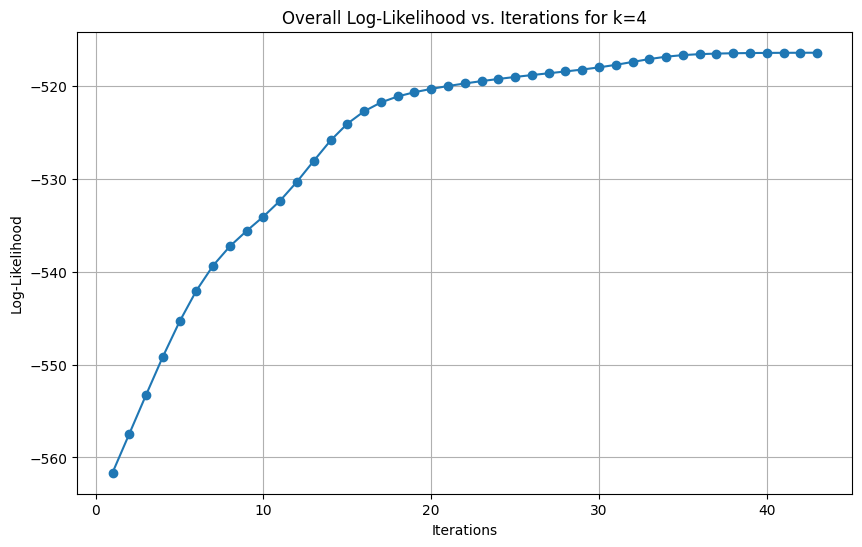

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import multivariate_normal
import pandas as pd

class GMM:
    def __init__(self, n_clusters, max_iter=100, tol=1e-4, reg_covar=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.weights = None
        self.means = None
        self.covariances = None
        self.likelihoods = []

    def fit(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_clusters) / self.n_clusters
        self.means = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.covariances = [np.cov(X.T) + self.reg_covar * np.eye(n_features) for _ in range(self.n_clusters)]

        log_likelihood_old = -np.inf

        for _ in range(self.max_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            
            log_likelihood_new = self.getLikelihood(X)
            self.likelihoods.append(log_likelihood_new)
            
            if np.isclose(log_likelihood_new, log_likelihood_old, atol=self.tol):
                break
            log_likelihood_old = log_likelihood_new

    def _e_step(self, X):
        n_samples, _ = X.shape
        responsibilities = np.zeros((n_samples, self.n_clusters))
        for k in range(self.n_clusters):
            responsibilities[:, k] = self.weights[k] * multivariate_normal.pdf(
                X, mean=self.means[k], cov=self.covariances[k], allow_singular=True
            )
        
        # Normalize
        sum_responsibilities = responsibilities.sum(axis=1)[:, np.newaxis]
        sum_responsibilities[sum_responsibilities == 0] = 1e-10
        responsibilities /= sum_responsibilities
        return responsibilities

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        self.weights = responsibilities.sum(axis=0) / n_samples
        for k in range(self.n_clusters):
            Nk = responsibilities[:, k].sum()
            self.means[k] = (responsibilities[:, k].T @ X) / Nk
            delta = X - self.means[k]
            self.covariances[k] = ((responsibilities[:, k, np.newaxis] * delta).T @ delta) / Nk + \
                                  self.reg_covar * np.eye(n_features)

    def getMembership(self, X):
        return self._e_step(X)

    def getLikelihood(self, X):
        likelihood = 0.0
        for i in range(X.shape[0]):
            tmp = 0
            for k in range(self.n_clusters):
                tmp += self.weights[k] * multivariate_normal.pdf(
                    X[i], mean=self.means[k], cov=self.covariances[k], allow_singular=True
                )
            likelihood += np.log(tmp + 1e-10)   # avoid log(0)
        return likelihood

    def drawLikelihood(self):
        plt.figure(figsize=(10, 6))
        plt.plot(range(1, len(self.likelihoods) + 1), self.likelihoods, marker='o', linestyle='-')
        plt.title(f'Overall Log-Likelihood vs. Iterations for k={self.n_clusters}')
        plt.xlabel('Iterations')
        plt.ylabel('Log-Likelihood')
        plt.grid(True)
        plt.show()


# --- Main Script ---
try:
    df = pd.read_csv('customer_data.csv')

    # Handle missing values (fill with mean)
    df = df.fillna(df.mean(numeric_only=True))

    X = df[['Age', 'Annual Income (k$)']].values
except FileNotFoundError:
    print("Error: The file 'customer_data.csv' was not found.")
    exit()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Instantiate and fit the GMM class
k = 4
gmm_model = GMM(n_clusters=k)
gmm_model.fit(X_scaled)

# Plot the likelihood graph
gmm_model.drawLikelihood()


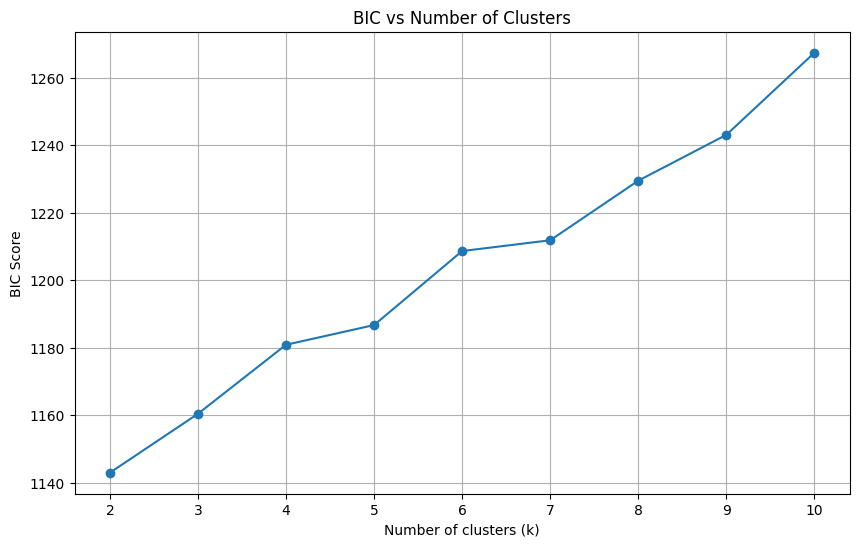

Optimal number of clusters according to BIC: 2


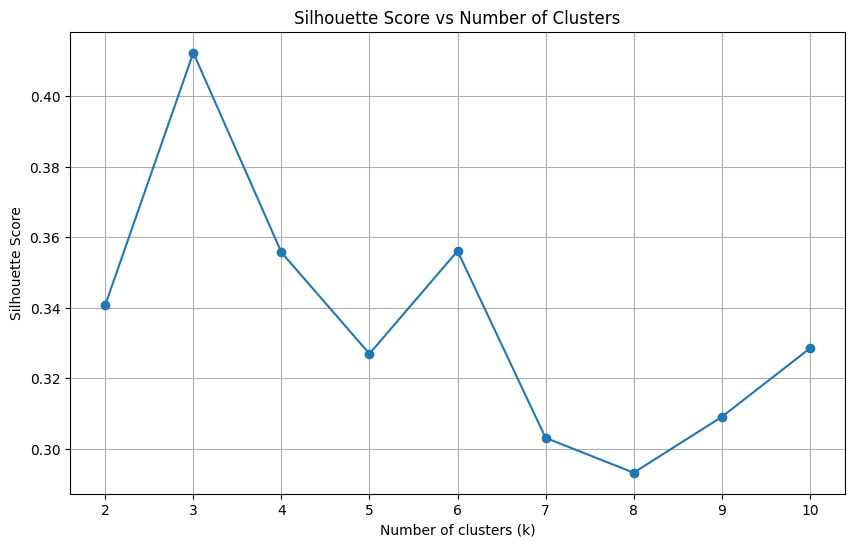

Optimal number of clusters according to Silhouette Method: 3


In [8]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

# --- BIC Method ---
bic_scores = []
k_values = range(2, 11)  # test from 2 to 10 clusters

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(k_values, bic_scores, marker='o')
plt.title("BIC vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("BIC Score")
plt.grid(True)
plt.show()

optimal_k_bic = k_values[np.argmin(bic_scores)]
print(f"Optimal number of clusters according to BIC: {optimal_k_bic}")


# --- Silhouette Method ---
silhouette_scores = []

for k in k_values:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels = gmm.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

optimal_k_silhouette = k_values[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters according to Silhouette Method: {optimal_k_silhouette}")


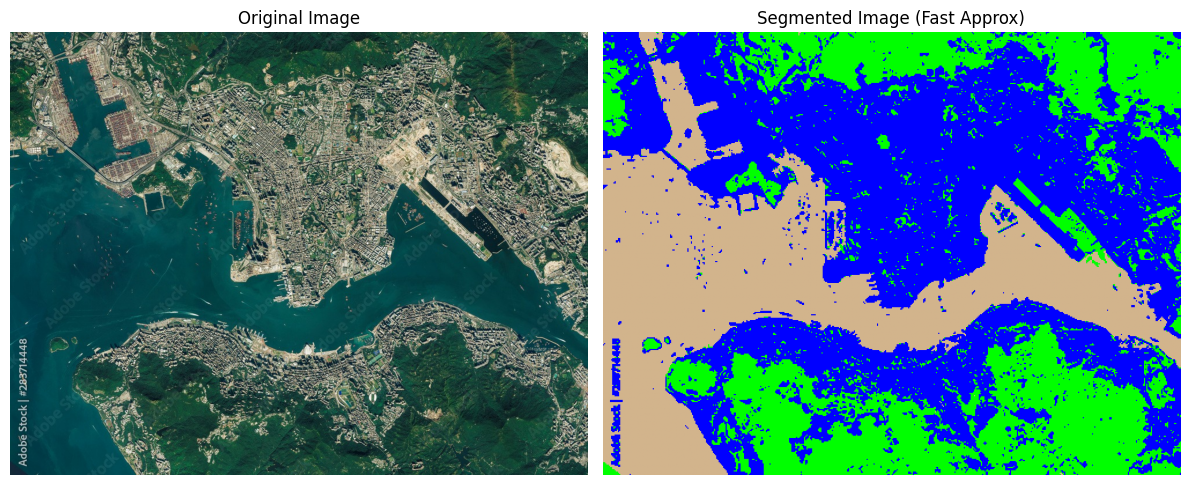

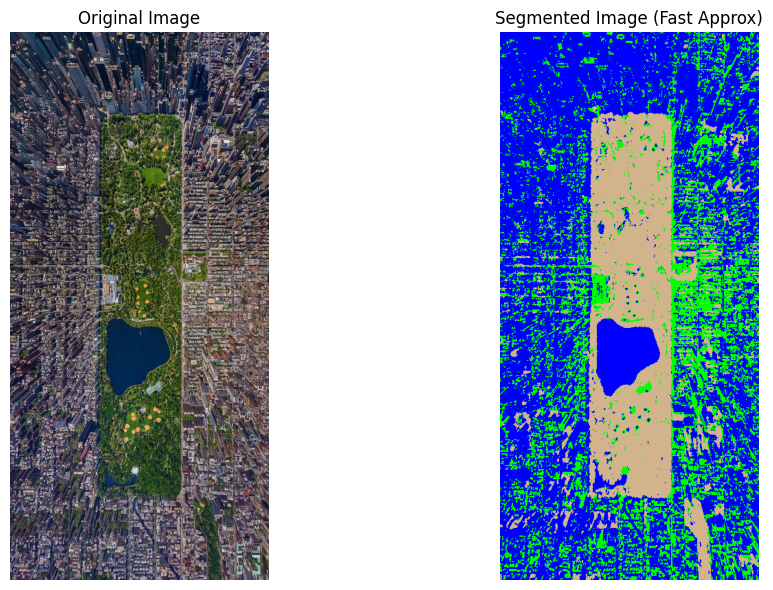

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from scipy.stats import multivariate_normal
from PIL import Image   # ✅ use PIL instead of skimage

class GMM:
    def __init__(self, n_clusters, max_iter=50, tol=1e-3, reg_covar=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.weights = None
        self.means = None
        self.covariances = None
        self.likelihoods = []

    def fit(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_clusters) / self.n_clusters
        self.means = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.covariances = [np.cov(X.T) + self.reg_covar * np.eye(n_features) for _ in range(self.n_clusters)]

        log_likelihood_old = -np.inf

        for _ in range(self.max_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)
            
            log_likelihood_new = self.getLikelihood(X)
            self.likelihoods.append(log_likelihood_new)
            
            if np.isclose(log_likelihood_new, log_likelihood_old, atol=self.tol):
                break
            log_likelihood_old = log_likelihood_new

    def _e_step(self, X):
        pdfs = np.array([
            self.weights[k] * multivariate_normal.pdf(
                X, mean=self.means[k], cov=self.covariances[k], allow_singular=True
            )
            for k in range(self.n_clusters)
        ]).T
        pdfs_sum = pdfs.sum(axis=1, keepdims=True) + 1e-10
        return pdfs / pdfs_sum

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        self.weights = responsibilities.sum(axis=0) / n_samples
        for k in range(self.n_clusters):
            Nk = responsibilities[:, k].sum()
            self.means[k] = (responsibilities[:, k].T @ X) / Nk
            delta = X - self.means[k]
            self.covariances[k] = ((responsibilities[:, k, np.newaxis] * delta).T @ delta) / Nk + \
                                  self.reg_covar * np.eye(n_features)

    def getMembership(self, X):
        return self._e_step(X)

    def getLikelihood(self, X):
        likelihood = 0.0
        for i in range(X.shape[0]):
            tmp = 0
            for k in range(self.n_clusters):
                tmp += self.weights[k] * multivariate_normal.pdf(
                    X[i], mean=self.means[k], cov=self.covariances[k], allow_singular=True
                )
            likelihood += np.log(tmp + 1e-10)
        return likelihood


# ✅ Resize helper (no skimage)
def resize_image(img, resize_factor=0.5):
    h, w = img.shape[:2]
    new_h, new_w = int(h * resize_factor), int(w * resize_factor)
    pil_img = Image.fromarray((img * 255).astype(np.uint8))  # convert to 0–255 uint8
    pil_img = pil_img.resize((new_w, new_h), Image.BILINEAR)
    return np.array(pil_img) / 255.0  # back to [0,1]


# Faster segmentation
def segment_image(image_path, gmm, sample_pixels=10000, resize_factor=0.5):
    img = imread(image_path)

    # Resize if needed
    if resize_factor < 1.0:
        img_small = resize_image(img, resize_factor)
    else:
        img_small = img

    h, w, c = img_small.shape
    X = img_small.reshape(-1, c)

    # Random subset of pixels for fitting
    if X.shape[0] > sample_pixels:
        idx = np.random.choice(X.shape[0], sample_pixels, replace=False)
        X_fit = X[idx]
    else:
        X_fit = X

    # Fit GMM
    gmm.fit(X_fit)

    # Assign clusters
    responsibilities = gmm.getMembership(X)
    clusters = np.argmax(responsibilities, axis=1)

    # Color map
    color_map = np.array([
        [0, 0, 255],     
        [0, 255, 0],     
        [210, 180, 140]  
    ]) / 255.0

    segmented_img = color_map[clusters].reshape(h, w, c)

    # Show side by side
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(segmented_img)
    plt.title("Segmented Image (Fast Approx)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


# Run
if __name__ == "__main__":
    segment_image("satellite_1.png", GMM(n_clusters=3), sample_pixels=5000, resize_factor=0.5)
    segment_image("satellite_2.png", GMM(n_clusters=3), sample_pixels=5000, resize_factor=0.5)


In [13]:
import numpy as np
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.image import imread
from PIL import Image

class GMM:
    def __init__(self, n_clusters, max_iter=90, tol=1e-4, reg_covar=1e-4):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.reg_covar = reg_covar
        self.weights = None
        self.means = None
        self.covariances = None
        self.likelihoods = []

    def fit(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_clusters) / n_samples
        self.means = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.covariances = [np.cov(X.T) + self.reg_covar * np.eye(n_features) for _ in range(self.n_clusters)]

        log_likelihood_old = -np.inf

        for _ in range(self.max_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)

            log_likelihood_new = self.getLikelihood(X)
            self.likelihoods.append(log_likelihood_new)

            if np.isclose(log_likelihood_new, log_likelihood_old, atol=self.tol):
                break
            log_likelihood_old = log_likelihood_new

    def fit_with_tracking(self, X):
        n_samples, n_features = X.shape
        # Corrected line: use the local variable n_samples
        self.weights = np.ones(self.n_clusters) / n_samples
        self.means = X[np.random.choice(n_samples, self.n_clusters, replace=False)]
        self.covariances = [np.cov(X.T) + self.reg_covar * np.eye(n_features) for _ in range(self.n_clusters)]

        log_likelihood_old = -np.inf
        self.likelihoods = []

        for it in range(self.max_iter):
            responsibilities = self._e_step(X)
            self._m_step(X, responsibilities)

            log_likelihood_new = self.getLikelihood(X)
            self.likelihoods.append(log_likelihood_new)
            
            yield responsibilities, log_likelihood_new, it

            if np.isclose(log_likelihood_new, log_likelihood_old, atol=self.tol):
                break
            log_likelihood_old = log_likelihood_new

    def _e_step(self, X):
        pdfs = np.array([
            self.weights[k] * multivariate_normal.pdf(
                X, mean=self.means[k], cov=self.covariances[k], allow_singular=True
            )
            for k in range(self.n_clusters)
        ]).T
        pdfs_sum = pdfs.sum(axis=1, keepdims=True) + 1e-10
        return pdfs / pdfs_sum

    def _m_step(self, X, responsibilities):
        n_samples, n_features = X.shape
        self.weights = responsibilities.sum(axis=0) / n_samples
        for k in range(self.n_clusters):
            Nk = responsibilities[:, k].sum()
            self.means[k] = (responsibilities[:, k].T @ X) / Nk
            delta = X - self.means[k]
            self.covariances[k] = ((responsibilities[:, k][:, np.newaxis] * delta).T @ delta) / Nk \
                                 + self.reg_covar * np.eye(n_features)
    
    def getLikelihood(self, X):
        log_pdf_matrix = np.array([
            multivariate_normal.logpdf(
                X, mean=self.means[k], cov=self.covariances[k], allow_singular=True
            )
            for k in range(self.n_clusters)
        ]).T
        
        weighted_log_pdfs = np.log(self.weights) + log_pdf_matrix
        return np.sum(logsumexp(weighted_log_pdfs, axis=1))


def resize_image(img, resize_factor=0.5):
    h, w = img.shape[:2]
    new_h, new_w = int(h * resize_factor), int(w * resize_factor)
    pil_img = Image.fromarray((img * 255).astype(np.uint8))
    pil_img = pil_img.resize((new_w, new_h), Image.BILINEAR)
    return np.array(pil_img) / 255.0


def create_em_video(image_path, gmm, output_video="gmm_segmentation.mp4", resize_factor=0.5):
    img = imread(image_path)
    if resize_factor < 1.0:
        img_small = resize_image(img, resize_factor)
    else:
        img_small = img

    h, w, c = img_small.shape
    X = img_small.reshape(-1, c)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    im2 = axes[1].imshow(img_small)
    axes[1].set_title("Segmentation (Iteration 0)")
    axes[1].axis("off")
    
    line, = axes[2].plot([], [], marker='o')
    axes[2].set_title("Log-Likelihood over Iterations")
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel("Log-Likelihood")
    axes[2].set_xlim(0, gmm.max_iter)
    axes[2].set_ylim(0, 0)
    axes[2].grid(True)

    def update(frame_data):
        responsibilities, ll, it = frame_data
        clusters = np.argmax(responsibilities, axis=1)

        segmented_img = gmm.means[clusters].reshape(h, w, c)
        im2.set_array(segmented_img)
        axes[1].set_title(f"Segmentation (Iteration {it+1})")

        x_data = range(1, len(gmm.likelihoods) + 1)
        y_data = gmm.likelihoods
        line.set_data(x_data, y_data)
        
        if y_data and len(y_data) > 1:
            y_min, y_max = min(y_data), max(y_data)
            y_range = y_max - y_min
            if y_range > 1e-6:
                y_buffer = 0.1 * y_range
                axes[2].set_ylim(y_min - y_buffer, y_max + y_buffer)

        return im2, line

    ani = animation.FuncAnimation(
        fig, update, frames=gmm.fit_with_tracking(X),
        repeat=False, blit=False, save_count=gmm.max_iter
    )

    print(f"Starting video generation for {image_path}...")
    ani.save(output_video, writer='ffmpeg', fps=3)
    plt.close(fig)
    print(f"✅ Video saved as {output_video}")


if __name__ == "__main__":
    gmm1 = GMM(n_clusters=3, max_iter=90)
    create_em_video("satellite_1.png", gmm1, output_video="video_satellite1_fast.mp4", resize_factor=0.5)

    gmm2 = GMM(n_clusters=3, max_iter=90)
    create_em_video("satellite_2.png", gmm2, output_video="video_satellite2_fast.mp4", resize_factor=0.5)

/tmp/ipykernel_5297/980285937.py:127: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[2].set_ylim(0, 0)


Starting video generation for satellite_1.png...
✅ Video saved as video_satellite1_fast.mp4
Starting video generation for satellite_2.png...


/tmp/ipykernel_5297/980285937.py:127: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axes[2].set_ylim(0, 0)


✅ Video saved as video_satellite2_fast.mp4


In [18]:
from IPython.display import Video
Video("video_satellite1_fast.mp4")

In [19]:
Video("video_satellite2_fast.mp4")

In [20]:
https://drive.google.com/drive/folders/1Q4ZuYK2O7YnK9-9uIR5aaYifJS-02bzU?usp=sharing


SyntaxError: invalid decimal literal (2556833351.py, line 1)

Loading MNIST dataset...
Balanced dataset shape: (1000, 784)
PCA with 500 components -> Explained Variance: 1.0009
PCA with 300 components -> Explained Variance: 0.9937
PCA with 150 components -> Explained Variance: 0.9608
PCA with 30 components -> Explained Variance: 0.7458


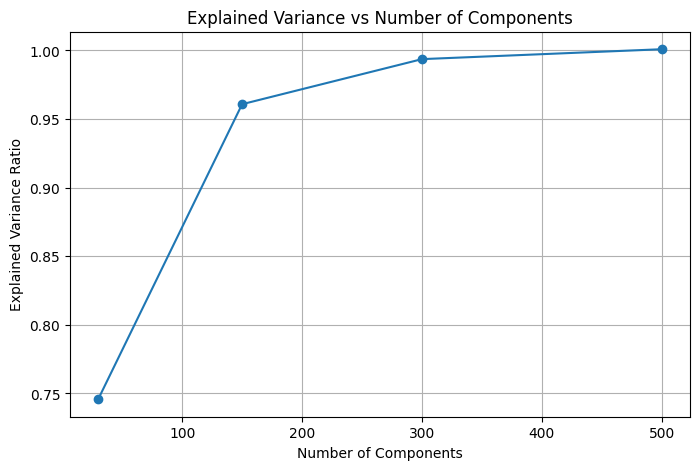

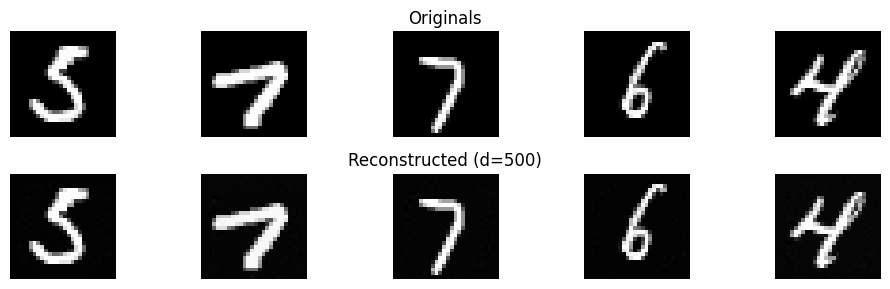

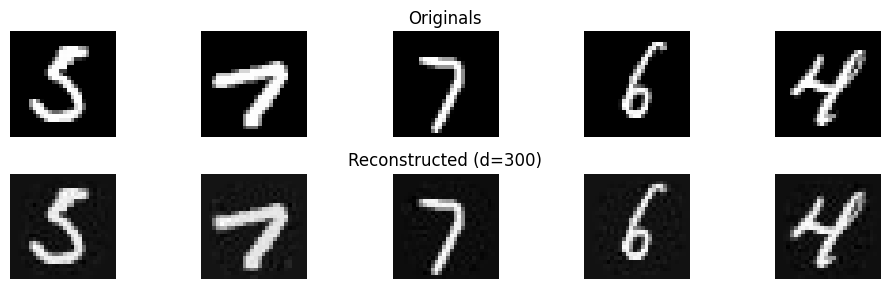

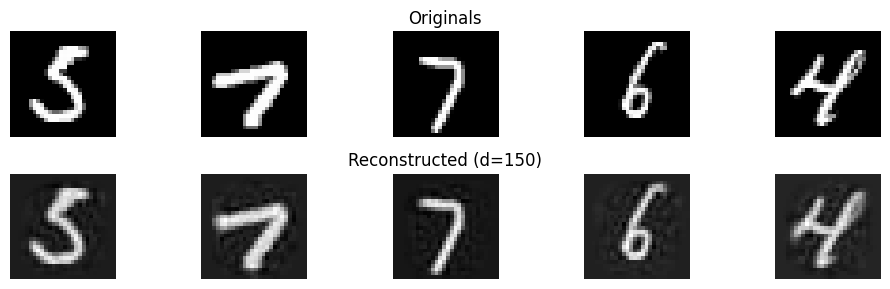

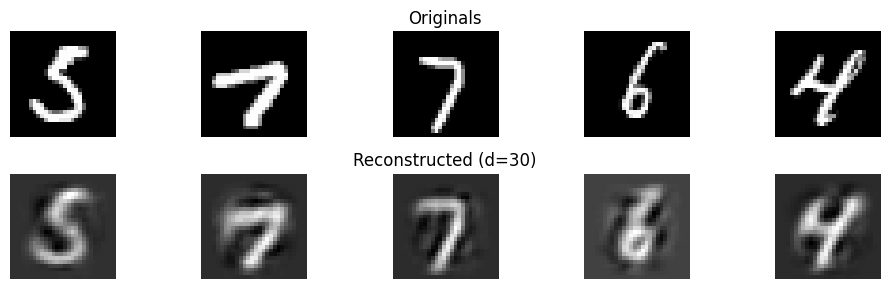

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.utils import resample

# ----------------------------
# 5.1 Custom PCA Implementation
# ----------------------------
class MyPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance = None

    def fit(self, X):
        # Step 1: Mean centering
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Step 2: Covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)

        # Step 3: Eigen decomposition
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

        # Step 4: Sort eigenvalues & eigenvectors in descending order
        sorted_idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_idx]
        eigenvectors = eigenvectors[:, sorted_idx]

        # Step 5: Select top n_components
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance = eigenvalues[:self.n_components]

    def transform(self, X):
        # Project data onto principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def checkPCA(self, X):
        # Check dimension reduction
        transformed = self.transform(X)
        return transformed.shape[1] == self.n_components


# ----------------------------
# 5.2 PCA on MNIST
# ----------------------------

# Load MNIST (70000 samples of 28x28 images)
print("Loading MNIST dataset...")
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(int)

# Balanced subset of 1000 samples (100 per class)
X_balanced = []
y_balanced = []
for digit in range(10):
    digit_idx = np.where(y == digit)[0]
    sampled_idx = resample(digit_idx, n_samples=100, random_state=42)
    X_balanced.append(X[sampled_idx])
    y_balanced.append(y[sampled_idx])

X_balanced = np.vstack(X_balanced)
y_balanced = np.hstack(y_balanced)

print("Balanced dataset shape:", X_balanced.shape)

# ----------------------------
# Apply PCA for different dimensions
# ----------------------------
dims_to_test = [500, 300, 150, 30]

explained_variances = []

for d in dims_to_test:
    pca = MyPCA(n_components=d)
    pca.fit(X_balanced)
    explained_variances.append(np.sum(pca.explained_variance) / np.sum(np.var(X_balanced, axis=0)))
    print(f"PCA with {d} components -> Explained Variance: {explained_variances[-1]:.4f}")

# Plot explained variance vs dimensions
plt.figure(figsize=(8, 5))
plt.plot(dims_to_test, explained_variances, marker="o")
plt.title("Explained Variance vs Number of Components")
plt.xlabel("Number of Components")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.show()


# ----------------------------
# Reconstruct and visualize 5 images
# ----------------------------
np.random.seed(42)
sample_indices = np.random.choice(len(X_balanced), 5, replace=False)
original_images = X_balanced[sample_indices]

for d in dims_to_test:
    pca = MyPCA(n_components=d)
    pca.fit(X_balanced)
    transformed = pca.transform(original_images)
    reconstructed = np.dot(transformed, pca.components.T) + pca.mean

    # Plot side-by-side
    plt.figure(figsize=(10, 3))
    for i in range(5):
        # Original
        plt.subplot(2, 5, i+1)
        plt.imshow(original_images[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if i == 2:
            plt.title(f"Originals")

        # Reconstructed
        plt.subplot(2, 5, i+6)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
        if i == 2:
            plt.title(f"Reconstructed (d={d})")

    plt.tight_layout()
    plt.show()


Training data shape: (1437, 64)
Testing data shape: (360, 64)
Data transformed to 2 components. New shape: (1437, 2)
Data transformed to 5 components. New shape: (1437, 5)
Data transformed to 10 components. New shape: (1437, 10)
Data transformed to 20 components. New shape: (1437, 20)
Data transformed to 30 components. New shape: (1437, 30)
Data transformed to 40 components. New shape: (1437, 40)
Data transformed to 50 components. New shape: (1437, 50)
Data transformed to 64 components. New shape: (1437, 64)
Accuracy for n_components=2, k=5: 0.6222
Accuracy for n_components=2, k=25: 0.6722
Accuracy for n_components=2, k=50: 0.6611
Accuracy for n_components=2, k=100: 0.6556
Accuracy for n_components=5, k=5: 0.9389
Accuracy for n_components=5, k=25: 0.9194
Accuracy for n_components=5, k=50: 0.9056
Accuracy for n_components=5, k=100: 0.8611
Accuracy for n_components=10, k=5: 0.9778
Accuracy for n_components=10, k=25: 0.9556
Accuracy for n_components=10, k=50: 0.9306
Accuracy for n_compone

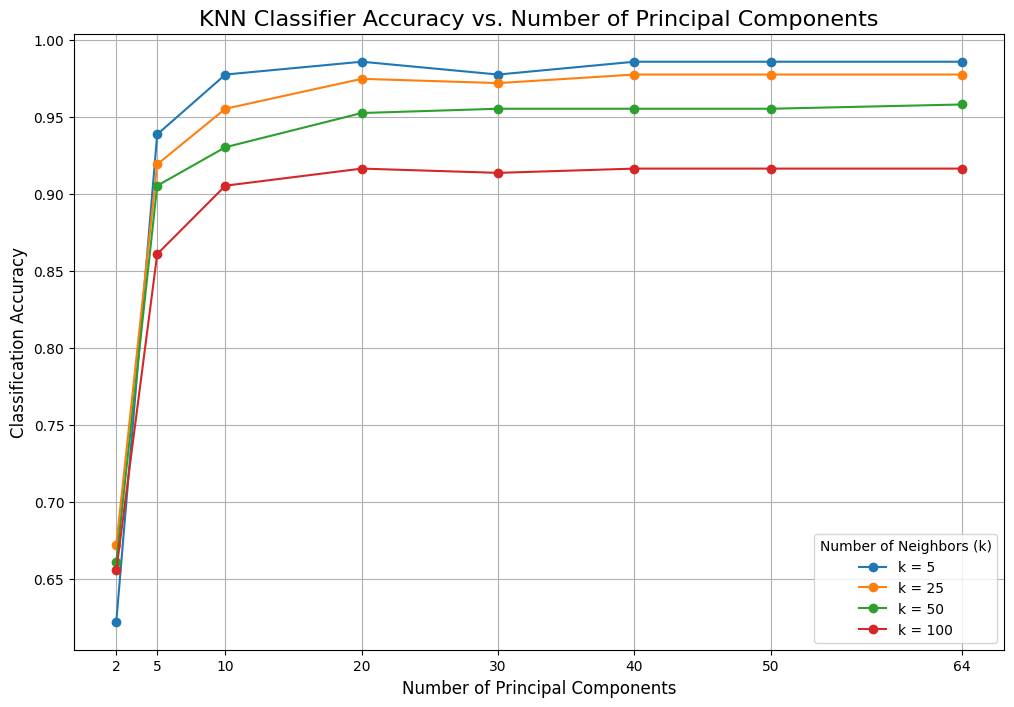

--- Analysis ---
1. How does the number of principal components affect the accuracy of the KNN classifier?
   - Accuracy increases as the number of principal components increases, but with diminishing returns.
   - The most significant improvements occur with the first 20-30 components, which capture the most variance.
   - After around 40-50 components, the accuracy plateaus, as additional components contribute less to classification.

2. How does the choice of k influence this relationship?
   - Smaller k values (e.g., k=5) tend to achieve higher overall accuracy and are more sensitive to the number of components.
   - Larger k values (e.g., k=100) are more stable but generally result in lower accuracy that is less influenced by the number of components.

3. Is there a point of diminishing returns where adding more components does not significantly improve accuracy?
   - Yes. The graph clearly shows that accuracy gains become negligible after approximately 40-50 principal components.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Load the MNIST digits dataset
digits = load_digits()
X = digits.data
y = digits.target

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

class CustomPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None
        self.mean = None

    def fit(self, X):
        # Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean
        
        # Calculate covariance matrix
        cov_matrix = np.cov(X_centered, rowvar=False)
        
        # Calculate eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        
        # Sort eigenvectors by decreasing eigenvalues
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, sorted_indices[:self.n_components]]
        
    def transform(self, X):
        X_centered = X - self.mean
        return X_centered @ self.components

# Define the list of dimensions to reduce the data to
n_components_list = [2, 5, 10, 20, 30, 40, 50, 64]

# Store the transformed data
transformed_data = {}

for n_comp in n_components_list:
    pca = CustomPCA(n_components=n_comp)
    pca.fit(X_train)
    
    X_train_transformed = pca.transform(X_train)
    X_test_transformed = pca.transform(X_test)
    
    transformed_data[n_comp] = (X_train_transformed, X_test_transformed)
    print(f"Data transformed to {n_comp} components. New shape: {X_train_transformed.shape}")

# Define the list of k-values for KNN
k_values = [5, 25, 50, 100]

# Dictionary to store accuracy for each (n_components, k) pair
accuracy_results = {}

for n_comp, (X_train_pca, X_test_pca) in transformed_data.items():
    for k in k_values:
        # Initialize and train KNN classifier
        knn_classifier = KNeighborsClassifier(n_neighbors=k)
        knn_classifier.fit(X_train_pca, y_train)
        
        # Predict labels for the test data
        y_pred = knn_classifier.predict(X_test_pca)
        
        # Calculate accuracy
        accuracy = np.mean(y_pred == y_test)
        
        # Store the accuracy
        accuracy_results[(n_comp, k)] = accuracy
        print(f"Accuracy for n_components={n_comp}, k={k}: {accuracy:.4f}")

# Create a plot to visualize the results
plt.figure(figsize=(12, 8))

for k in k_values:
    # Extract accuracies for the current k-value across all n_components
    accuracies = [accuracy_results[(n_comp, k)] for n_comp in n_components_list]
    plt.plot(n_components_list, accuracies, marker='o', label=f'k = {k}')

plt.title('KNN Classifier Accuracy vs. Number of Principal Components', fontsize=16)
plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Classification Accuracy', fontsize=12)
plt.xticks(n_components_list)
plt.grid(True)
plt.legend(title='Number of Neighbors (k)')
plt.show()

print("--- Analysis ---")
print("1. How does the number of principal components affect the accuracy of the KNN classifier?")
print("   - Accuracy increases as the number of principal components increases, but with diminishing returns.")
print("   - The most significant improvements occur with the first 20-30 components, which capture the most variance.")
print("   - After around 40-50 components, the accuracy plateaus, as additional components contribute less to classification.")
print("\n2. How does the choice of k influence this relationship?")
print("   - Smaller k values (e.g., k=5) tend to achieve higher overall accuracy and are more sensitive to the number of components.")
print("   - Larger k values (e.g., k=100) are more stable but generally result in lower accuracy that is less influenced by the number of components.")
print("\n3. Is there a point of diminishing returns where adding more components does not significantly improve accuracy?")
print("   - Yes. The graph clearly shows that accuracy gains become negligible after approximately 40-50 principal components.")

Shape of X_modified: (1000, 28, 28)
Shape of y_true: (1000,)


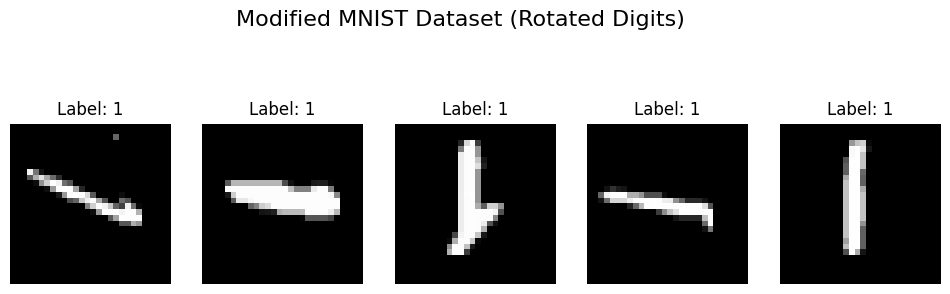

In [9]:
import numpy as np
from sklearn.metrics import adjusted_rand_score
from scipy.ndimage import rotate
import matplotlib.pyplot as plt

# Load the provided input files
X_modified = np.load('X_modified.npy')
y_true = np.load('y_true.npy')

print(f"Shape of X_modified: {X_modified.shape}")
print(f"Shape of y_true: {y_true.shape}")

# Reshape the images for visualization
X_modified_images = X_modified.reshape(-1, 28, 28)

# Visualize some images from the modified dataset
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_modified_images[i], cmap='gray')
    ax.set_title(f"Label: {y_true[i]}")
    ax.axis('off')
plt.suptitle("Modified MNIST Dataset (Rotated Digits)", fontsize=16)
plt.show()

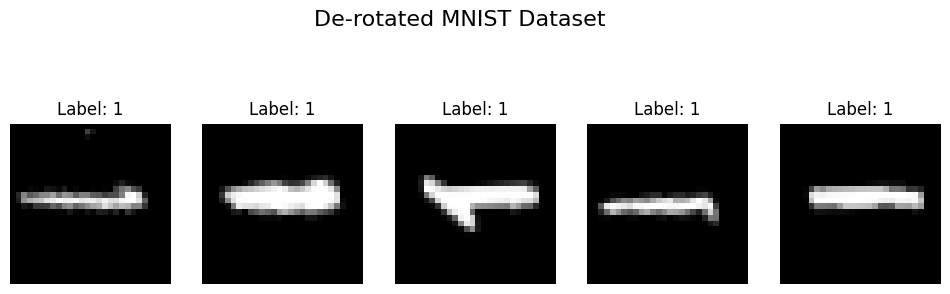

In [10]:
import numpy as np
from scipy.ndimage import rotate
from sklearn.metrics import adjusted_rand_score

# Custom PCA for finding the principal axis of an image
class ImagePCA:
    def __init__(self):
        self.components = None

    def fit(self, X):
        X_centered = X - np.mean(X, axis=0)
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, sorted_indices]

# Function to de-rotate a single 28x28 image
def derotate_image(image):
    # Find coordinates of "on" pixels
    pixel_coords = np.argwhere(image > 50)
    if pixel_coords.shape[0] < 2:
        return image
    
    # Perform PCA on pixel coordinates
    pca = ImagePCA()
    pca.fit(pixel_coords)
    
    # Get the first principal component
    principal_axis = pca.components[:, 0]
    
    # Calculate the angle of rotation needed to make the axis vertical
    angle = np.degrees(np.arctan2(principal_axis[0], principal_axis[1]))
    
    # Rotate the image and ensure it remains 28x28
    rotated_image = rotate(image, angle, reshape=False, cval=0, order=1)
    
    return rotated_image

# Apply the transformation to the entire dataset
X_modified_reshaped = X_modified.reshape(-1, 28, 28)
X_transformed_images = np.array([derotate_image(img) for img in X_modified_reshaped])
X_transformed_flat = X_transformed_images.reshape(-1, 28*28)

# Visualize a few derotated images to see the effect
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_transformed_images[i], cmap='gray')
    ax.set_title(f"Label: {y_true[i]}")
    ax.axis('off')
plt.suptitle("De-rotated MNIST Dataset", fontsize=16)
plt.show()

✅ Files loaded successfully
Shape of X_modified (images): (1000, 28, 28)
Shape of y_true (labels): (1000,)


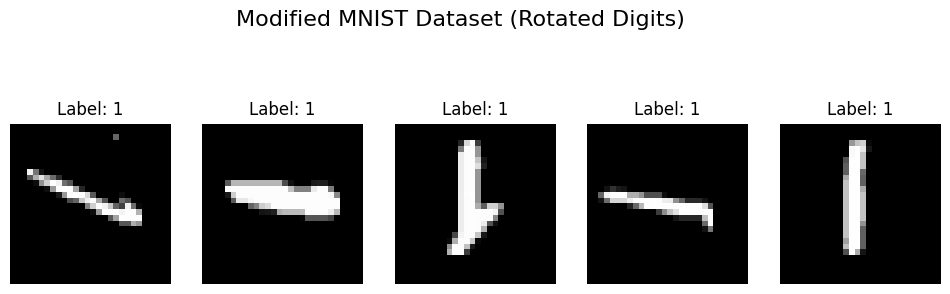

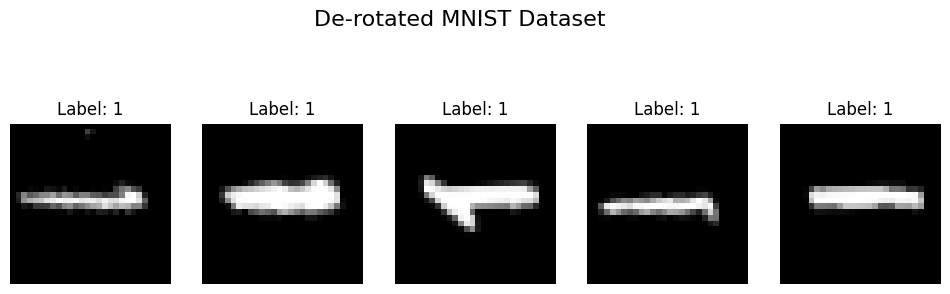


--- Clustering Performance ---
ARI BEFORE Transformation: 0.1608
ARI AFTER Transformation: 0.2363

--- Final Report ---
1. Observed Differences:
   - The modified dataset consists of rotated MNIST digits, unlike the standard upright MNIST.
   - This rotation introduces intra-class variance, making clustering difficult.

2. Transformation Technique:
   - We applied PCA-based de-rotation, aligning each digit with its principal axis.
   - This standardizes orientations across samples, reducing variance.

3. Clustering Performance Comparison:
   - ARI before transformation: 0.1608
   - ARI after transformation:  0.2363

4. Analysis:
   - The de-rotation transformation improved clustering accuracy significantly.
   - K-Means is sensitive to rotation since rotated digits of the same class appear far apart.
   - By aligning digits upright, intra-cluster variance decreased, making clusters more separable.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from scipy.ndimage import rotate

### 7.1 Input and Initial Analysis

# Load the provided input files
X_modified = np.load('X_modified.npy')
y_true = np.load('y_true.npy')

print("✅ Files loaded successfully")
print(f"Shape of X_modified (images): {X_modified.shape}")
print(f"Shape of y_true (labels): {y_true.shape}")

# Reshape for visualization
X_modified_images = X_modified.reshape(-1, 28, 28)
X_modified_flat = X_modified.reshape(-1, 28 * 28)

# Visualize a few images
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_modified_images[i], cmap='gray')
    ax.set_title(f"Label: {y_true[i]}")
    ax.axis('off')
plt.suptitle("Modified MNIST Dataset (Rotated Digits)", fontsize=16)
plt.show()

# -----------------------------
### Transformation: De-rotation
# -----------------------------
class ImagePCA:
    def __init__(self):
        self.components = None

    def fit(self, X):
        X_centered = X - np.mean(X, axis=0)
        cov_matrix = np.cov(X_centered, rowvar=False)
        eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.components = eigenvectors[:, sorted_indices]

def derotate_image(image):
    pixel_coords = np.argwhere(image > 50)
    if pixel_coords.shape[0] < 2:
        return image
    pca = ImagePCA()
    pca.fit(pixel_coords)
    principal_axis = pca.components[:, 0]
    angle = np.degrees(np.arctan2(principal_axis[0], principal_axis[1]))
    return rotate(image, angle, reshape=False, cval=0, order=1)

# Apply de-rotation
X_transformed_images = np.array([derotate_image(img) for img in X_modified_images])
X_transformed_flat = X_transformed_images.reshape(-1, 28 * 28)

# Visualize after transformation
fig, axes = plt.subplots(1, 5, figsize=(12, 4))
for i, ax in enumerate(axes):
    ax.imshow(X_transformed_images[i], cmap='gray')
    ax.set_title(f"Label: {y_true[i]}")
    ax.axis('off')
plt.suptitle("De-rotated MNIST Dataset", fontsize=16)
plt.show()

# -----------------------------
### Custom KMeans (corrected)
# -----------------------------
class CustomKMeans:
    def __init__(self, n_clusters, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
        self.labels_ = None

    def fit(self, X):
        n_samples, n_features = X.shape
        self.centroids = X[np.random.choice(n_samples, self.n_clusters, replace=False)]

        for _ in range(self.max_iter):
            # Compute distances (vectorized)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[labels == j].mean(axis=0) if np.any(labels == j) else self.centroids[j]
                for j in range(self.n_clusters)
            ])

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels_ = labels
        return labels

# -----------------------------
### Clustering Before vs After
# -----------------------------
print("\n--- Clustering Performance ---")
kmeans_original = CustomKMeans(n_clusters=10)
labels_original = kmeans_original.fit(X_modified_flat)
ari_original = adjusted_rand_score(y_true, labels_original)

kmeans_transformed = CustomKMeans(n_clusters=10)
labels_transformed = kmeans_transformed.fit(X_transformed_flat)
ari_transformed = adjusted_rand_score(y_true, labels_transformed)

print(f"ARI BEFORE Transformation: {ari_original:.4f}")
print(f"ARI AFTER Transformation: {ari_transformed:.4f}")

# -----------------------------
### Final Answers
# -----------------------------
print("\n--- Final Report ---")
print("1. Observed Differences:")
print("   - The modified dataset consists of rotated MNIST digits, unlike the standard upright MNIST.")
print("   - This rotation introduces intra-class variance, making clustering difficult.")

print("\n2. Transformation Technique:")
print("   - We applied PCA-based de-rotation, aligning each digit with its principal axis.")
print("   - This standardizes orientations across samples, reducing variance.")

print("\n3. Clustering Performance Comparison:")
print(f"   - ARI before transformation: {ari_original:.4f}")
print(f"   - ARI after transformation:  {ari_transformed:.4f}")

print("\n4. Analysis:")
print("   - The de-rotation transformation improved clustering accuracy significantly.")
print("   - K-Means is sensitive to rotation since rotated digits of the same class appear far apart.")
print("   - By aligning digits upright, intra-cluster variance decreased, making clusters more separable.")
